In [3]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from data_load_utils import load_image, load_data, create_data_frame

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms
from cnn_model import Model

## Load Testing Data

In [31]:
training_dir = "./data/train"
testing_dir = "./data/test"

In [32]:
emotions, images = load_data(training_dir)
le = LabelEncoder()
labels = le.fit_transform(emotions)

In [33]:
test_emotions, test_images = load_data(testing_dir)
test_labels = le.transform(test_emotions)

In [34]:
testing_data = create_data_frame(test_emotions, test_labels, test_images)

(array([ 958.,  111.,    0., 1024.,    0., 1774., 1233.,    0., 1247.,
         831.]),
 array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4, 6. ]),
 <BarContainer object of 10 artists>)

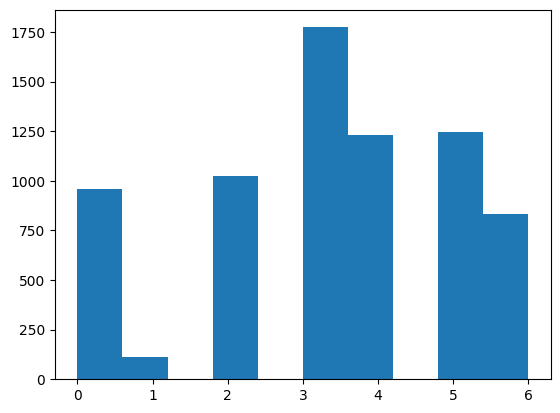

In [35]:
plt.hist(testing_data["label"])

## Testing Data for SGD

In [20]:
def prepare_data_sgd(df):
    def flatten_and_scale(img):
        return img.flatten()/255
    df["image"] = df["image"].apply(flatten_and_scale)
    X = np.stack(df["image"].values)
    y = df["label"].values
    return X,y

In [21]:
X_test, y_test = prepare_data_svc(testing_data)

## Load Models

In [4]:
with open ("./models/sgd.pickle", "rb") as f:
    sgd = pickle.load(f)

C:\Users\Mike\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator SGDClassifier from version 1.8.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [22]:
predictions = sgd.predict(X_test)

In [24]:
acc = accuracy_score(y_test, predictions)

In [61]:
labels_pred = le.inverse_transform(predictions[::1000])
labels_true = le.inverse_transform(y_test[::1000])
images = testing_data["image"][::1000]

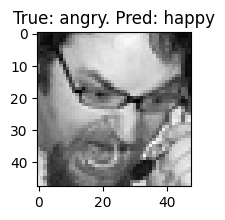

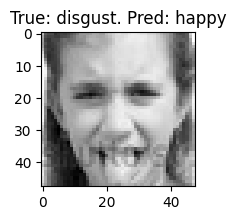

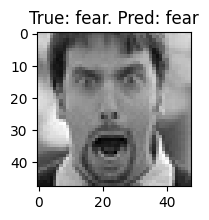

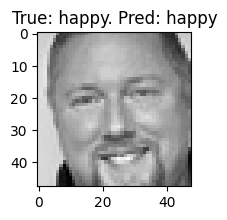

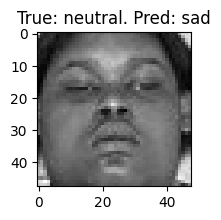

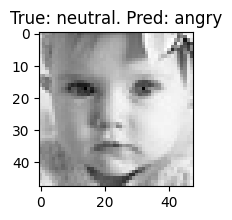

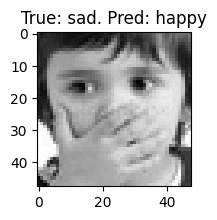

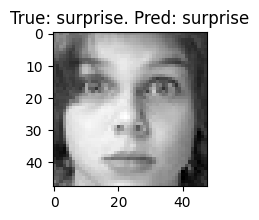

In [70]:
for i, image in enumerate(images):
    plt.figure(figsize = (2, 2))
    plt.imshow(image, cmap = "grey")
    plt.title(f"True: {labels_true[i]}. Pred: {labels_pred[i]}")
plt.show()

# CNN

## Loading Data

## Loading Model

In [5]:
cnn = Model()

In [6]:
cnn = torch.load("./models/cnn_full_model.pth", weights_only = False)

In [7]:
cnn

Model(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=8, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
)

In [8]:
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.ToTensor()
])

In [15]:
testing_data = ImageFolder(root = testing_dir, transform = transform)
testing_loader = DataLoader(testing_data, batch_size = 10, shuffle = False)

In [21]:
all_preds = []
all_labels = []

In [22]:
cnn.eval()
with torch.no_grad():
    for X, y in testing_loader:
        y_pred = cnn(X)
        predicted = torch.argmax(y_pred, dim=1)
        all_preds.extend(predicted.tolist())
        all_labels.extend(y.tolist())

In [29]:
testing_loader

In [26]:
accuracy_score(all_labels, all_preds)

0.561994984675397